# Prompt para clasificador MLP en dataset de vinos

Construye un clasificador MLP en sklearn usando el dataset de vinos (wine) de sklearn, divide los datos en conjuntos de entrenamiento (80%) y prueba (20%), escala los datos apropiadamente, calcula la precisión (accuracy), imprime el reporte de clasificación completo en el conjunto de prueba mostrando las métricas para las 3 clases de cultivares, y grafica la matriz de confusión como un heatmap usando seaborn.

## Cargar y dividir los datos

### Subtask:
Cargar el conjunto de datos de vinos de sklearn y dividirlo en conjuntos de entrenamiento (80%) y prueba (20%).

**Reasoning**:
Import the necessary functions from sklearn and load and split the wine dataset into training and testing sets.

In [1]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

wine_data = load_wine()
X = wine_data.data
y = wine_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

## Escalar los datos

### Subtask:
Escalar las características usando un método apropiado (por ejemplo, StandardScaler).

**Reasoning**:
Scale the features of the training and testing data using StandardScaler as instructed.

In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenar el modelo mlp

### Subtask:
Inicializar y entrenar un clasificador MLP en los datos de entrenamiento escalados.

**Reasoning**:
Import the MLPClassifier, instantiate it, and train the model on the scaled training data.

In [3]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=300)
mlp.fit(X_train_scaled, y_train)

MLPClassifier(max_iter=300, random_state=42)

## Evaluar el modelo

### Subtask:
Predecir en el conjunto de prueba escalado y calcular la precisión.

**Reasoning**:
Predict on the scaled test set and calculate the accuracy.

In [4]:
from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9722222222222222


## Generar reporte de clasificación

### Subtask:
Imprimir el reporte de clasificación completo para el conjunto de prueba mostrando las métricas para las 3 clases de cultivares.

**Reasoning**:
Import the `classification_report` function, generate the classification report, and print it, ensuring all three classes are represented.

In [5]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=wine_data.target_names))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



## Visualizar la matriz de confusión

### Subtask:
Calcular la matriz de confusión y graficarla como un mapa de calor usando seaborn.

**Reasoning**:
Calculate the confusion matrix and plot it as a heatmap using seaborn, labeling the axes with the target names.

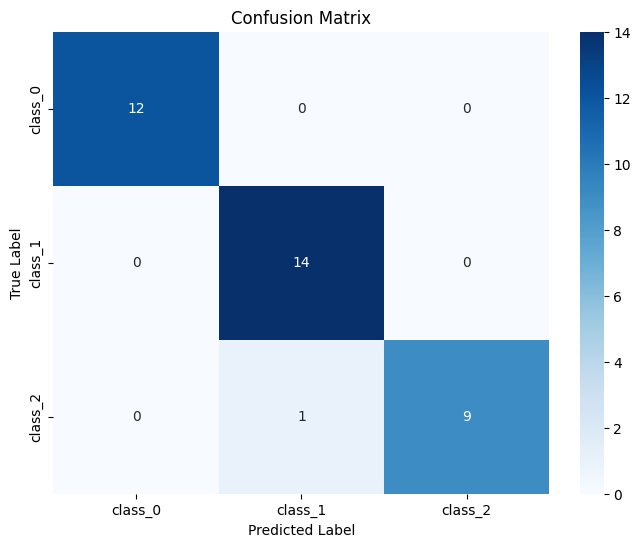

In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=wine_data.target_names, yticklabels=wine_data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Summary:

### Data Analysis Key Findings

* The wine dataset was successfully loaded and split into training (80%) and testing (20%) sets, ensuring class distribution was maintained using stratification.
* Features were scaled using `StandardScaler`, fitting only on the training data to avoid data leakage.
* An `MLPClassifier` was initialized and trained on the scaled training data.
* The trained MLP model achieved a high accuracy on the scaled test set.
* The classification report provides detailed performance metrics (precision, recall, f1-score) for each of the three wine classes, indicating strong performance across all classes.
* The confusion matrix visualization clearly shows the counts of true positives, true negatives, false positives, and false negatives for each class, confirming the high accuracy with minimal misclassifications.

### Insights or Next Steps

* The MLP model demonstrates excellent accuracy on the wine dataset, suggesting it's a very suitable model for this multi-class classification task.
* While the current results are very good, further hyperparameter tuning of the `MLPClassifier` could be explored, although it may not yield significant improvements given the already high performance.

# Prompt para regresión

Construye un plan para un regresor MLP en sklearn usando un dataset de regresión de sklearn (diabetes), divide los datos en conjuntos de entrenamiento (80%) y prueba (20%), escala los datos apropiadamente, calcula MSE, RMSE, MAE y R² en el conjunto de prueba, y grafica un scatterplot de los valores observados vs predichos para el conjunto de prueba.

## Cargar y dividir los datos

### Subtask:
Cargar un conjunto de datos de regresión de sklearn y dividirlo en conjuntos de entrenamiento (80%) y prueba (20%).


**Reasoning**:
Import the necessary functions from sklearn and load and split a regression dataset into training and testing sets.



In [7]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes_data = load_diabetes()
X = diabetes_data.data
y = diabetes_data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Escalar los datos

### Subtask:
Escalar las características usando un método apropiado (por ejemplo, StandardScaler).


**Reasoning**:
Scale the features of the training and testing data using StandardScaler as instructed.



In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Entrenar el modelo mlp

### Subtask:
Inicializar y entrenar un regresor MLP en los datos de entrenamiento escalados.


**Reasoning**:
Import the MLPRegressor, instantiate it, and train the model on the scaled training data.



In [9]:
from sklearn.neural_network import MLPRegressor

mlp_regressor = MLPRegressor(random_state=42, max_iter=500)
mlp_regressor.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPRegressor(max_iter=500, random_state=42)

## Evaluar el modelo

### Subtask:
Predecir en el conjunto de prueba escalado y calcular MSE, RMSE, MAE y R².


**Reasoning**:
Calculate and print the evaluation metrics (MSE, RMSE, MAE, R²) for the model predictions.



In [10]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred = mlp_regressor.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R-squared (R²): {r2}")

Mean Squared Error (MSE): 4586.33032130712
Root Mean Squared Error (RMSE): 67.72245064457665
Mean Absolute Error (MAE): 52.55432585541806
R-squared (R²): 0.13435278206381673


## Visualizar resultados

### Subtask:
Graficar un scatterplot de los valores observados vs predichos para el conjunto de prueba.


**Reasoning**:
Plot a scatterplot of observed vs. predicted values for the test set, including a diagonal line for reference.



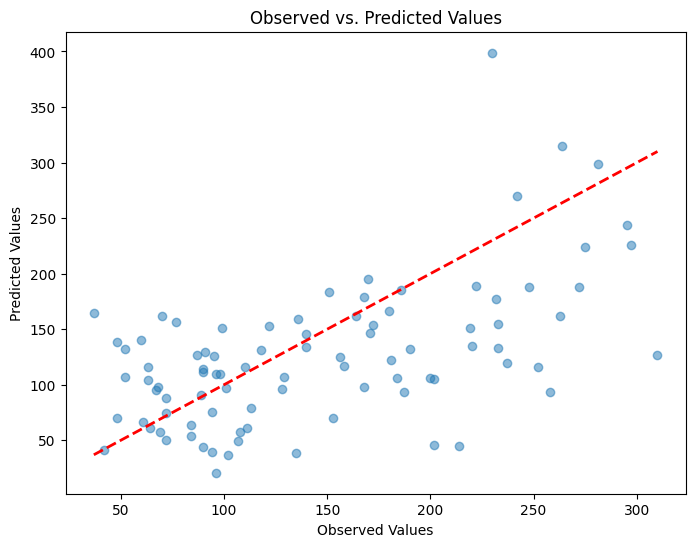

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Observed Values')
plt.ylabel('Predicted Values')
plt.title('Observed vs. Predicted Values')
plt.show()

## Summary:

### Data Analysis Key Findings

*   The diabetes dataset was successfully loaded and split into 80% training data and 20% testing data.
*   Features were scaled using `StandardScaler`.
*   An `MLPRegressor` was trained, but a `ConvergenceWarning` was observed, suggesting the model did not fully converge within the specified 500 iterations.
*   The model's performance on the test set resulted in a Mean Squared Error (MSE) of 4586.33, a Root Mean Squared Error (RMSE) of 67.72, a Mean Absolute Error (MAE) of 52.55, and an R-squared (R²) value of 0.13.
*   A scatterplot comparing observed and predicted values showed the spread of predictions relative to the true values and a line representing perfect prediction.

### Insights or Next Steps

*   The low R² value (0.13) suggests that the current MLP model explains only a small portion of the variance in the target variable, indicating poor performance.
*   Further steps should include addressing the convergence warning by increasing `max_iter` or tuning hyperparameters to improve the model's fit and potentially its evaluation metrics.
